# 05 — Feature Engineering & Gestion des Catégories

**Objectif** : Enrichir les features existantes avec :
1. **Features d'interaction** (ratios, produits croisés)
2. **Encodage des variables catégorielles** (Target Encoding lissé pour les communes)
3. **Comparaison avant/après** sur les 3 cibles

**Pourquoi ?**  
Le `StandardScaler` actuel traite uniquement les variables numériques brutes. Les features construites capturent des relations non-linéaires (ex : `nb_enfants_0_14 = population × pop_0_14_pct / 100`) directement corrélées à la variable cible.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import shap

from p13.db import read_sql
from p13.ml.features import FEATURE_COLUMNS, ALL_TARGETS, ENGINEERED_FEATURES, FEATURE_COLUMNS_ENGINEERED
from p13.ml.feature_engineering import add_interaction_features, target_encode

sns.set_theme(style='whitegrid', palette='muted')
print('Librairies chargées.')

Librairies chargées.


## 1. Chargement des données

In [2]:
df_raw = read_sql("""
    SELECT *
    FROM ml_dataset_commune
    WHERE nb_eleves_maternelle IS NOT NULL
    ORDER BY code_insee, rentree
""")

print(f"Dataset : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes")
print(f"Communes : {df_raw['code_insee'].nunique()} | Rentrées : {sorted(df_raw['rentree'].unique())}")
df_raw.head(3)

Dataset : 688 lignes × 17 colonnes
Communes : 43 | Rentrées : [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,id,code_insee,rentree,nb_eleves_maternelle,nb_eleves_elementaire,nb_classes,population,pop_0_14_pct,natalite,densite,log_collectif,log_individuel,plh_logements,nb_mutations,nb_logements_parcelle,nb_batiments,nb_permis_logements
0,636,35001,2009,281.0,487.0,30.0,6874,20.0,7.4,233.0,91,2035,456,0,91058,147088,0
1,635,35001,2010,294.0,472.0,30.0,6874,20.0,7.4,233.0,91,2035,456,0,91058,147088,0
2,402,35001,2011,301.0,457.0,28.0,6874,20.0,7.4,233.0,91,2035,456,151,91058,147088,0


## 2. Features d'interaction et de ratio

| Feature construite | Formule | Justification |
|---|---|---|
| `nb_enfants_0_14` | `population × pop_0_14_pct / 100` | Nombre absolu d'enfants scolarisables |
| `taux_croissance_logements` | `nb_permis / population` | Pression démographique relative |
| `densite_natalite` | `densite × natalite` | Zones denses à fort renouvellement |
| `pct_collectif` | `log_collectif / total_logements` | Proxy urbain/rural |

In [3]:
df_eng = add_interaction_features(df_raw)

print("Nouvelles colonnes créées :")
for col in ENGINEERED_FEATURES:
    if col in df_eng.columns:
        print(f"  {col:35s} | mean={df_eng[col].mean():.3f} | std={df_eng[col].std():.3f}")

df_eng[ENGINEERED_FEATURES].describe()

Nouvelles colonnes créées :
  nb_enfants_0_14                     | mean=1871.007 | std=4797.524
  taux_croissance_logements           | mean=0.000 | std=0.000
  densite_natalite                    | mean=5688.198 | std=7833.106
  pct_collectif                       | mean=0.049 | std=0.041


,nb_enfants_0_14,taux_croissance_logements,densite_natalite,pct_collectif
count,688.000000,688.0,688.000000,688.000000
mean,1871.007047,0.0,5688.197674,0.049310
std,4797.523602,0.0,7833.106004,0.040602
min,111.705000,0.0,448.400000,0.003145
25%,531.216000,0.0,2441.500000,0.029213
50%,1018.670000,0.0,4060.800000,0.043226
75%,1518.480000,0.0,5757.000000,0.058993
max,32555.490000,0.0,52263.900000,0.280389


### 2.1 Corrélations avec les cibles

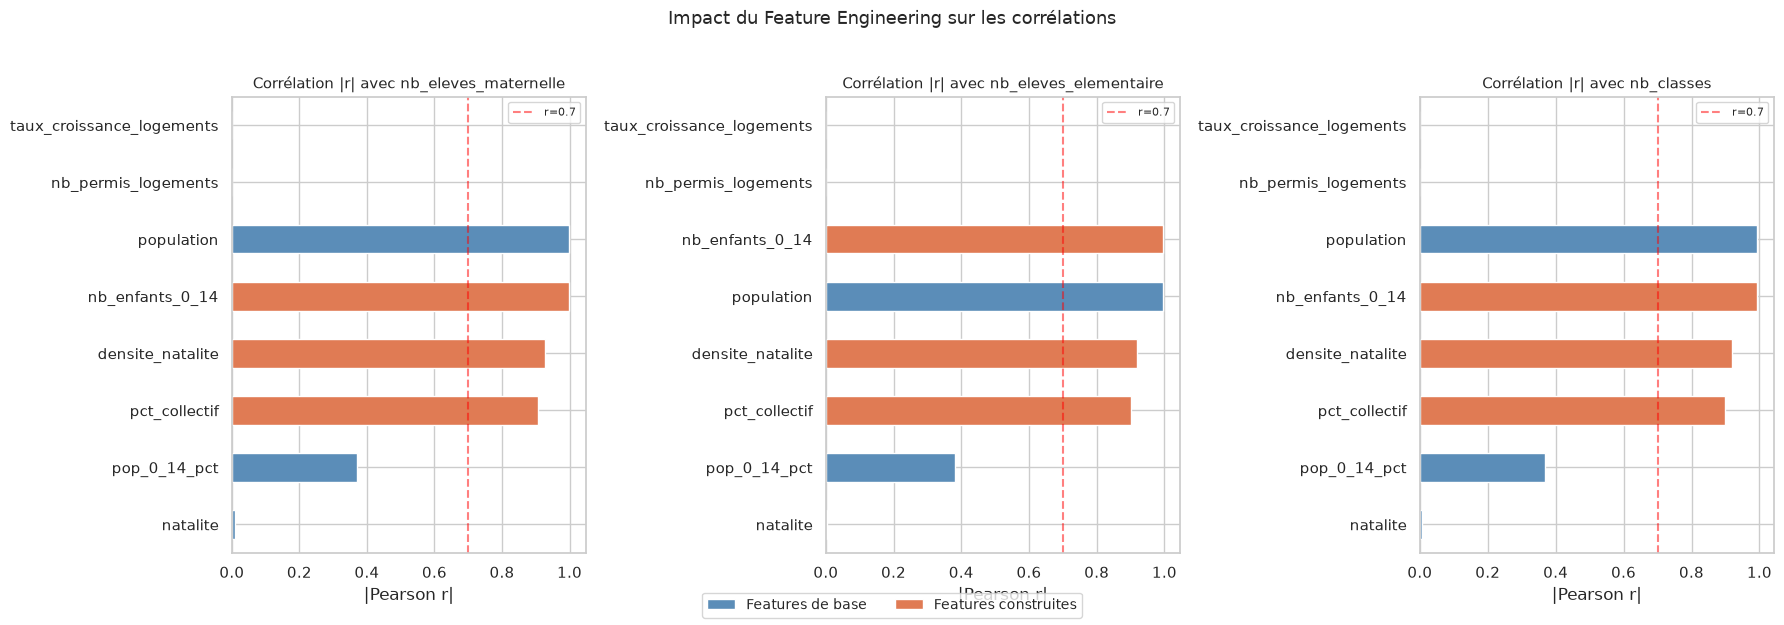

In [4]:
all_features = FEATURE_COLUMNS + [f for f in ENGINEERED_FEATURES if f in df_eng.columns]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, target in zip(axes, ALL_TARGETS):
    corrs = df_eng[all_features].corrwith(df_eng[target]).abs().sort_values(ascending=True)
    colors = ['#e07b54' if f in ENGINEERED_FEATURES else '#5b8db8' for f in corrs.index]
    corrs.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Corrélation |r| avec {target}', fontsize=11)
    ax.set_xlabel('|Pearson r|')
    ax.axvline(0.7, color='red', linestyle='--', alpha=0.5, label='r=0.7')
    ax.legend(fontsize=8)

# Légende manuelle
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#5b8db8', label='Features de base'),
    Patch(facecolor='#e07b54', label='Features construites'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10)
plt.suptitle('Impact du Feature Engineering sur les corrélations', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Encodage des variables catégorielles (communes)

Le `code_insee` est une variable catégorielle. On utilise le **Target Encoding lissé** (Bayesian smoothing) plutôt que le One-Hot Encoding pour éviter l'explosion dimensionnelle (41 communes → 41 colonnes binaires).

**Formule** : `encoded = (n × mean_commune + λ × mean_global) / (n + λ)` avec `λ=10`

In [5]:
target = 'nb_eleves_elementaire'

df_eng['commune_te'] = target_encode(
    df_eng,
    cat_col='code_insee',
    target_col=target,
    smoothing=10.0,
)

print(f"Target Encoding (λ=10) pour {target} :")
sample = df_eng[['code_insee', 'commune_te', target]].drop_duplicates('code_insee').sort_values('commune_te')
print(sample.head(10).to_string(index=False))

corr = df_eng['commune_te'].corr(df_eng[target])
print(f"\nCorrélation commune_te ↔ {target} : r = {corr:.4f}")

Target Encoding (λ=10) pour nb_eleves_elementaire :
code_insee  commune_te  nb_eleves_elementaire
     35022  257.569991                   46.0
     35180  266.493068                   71.0
     35081  267.531530                   65.0
     35144  274.146914                   71.0
     35315  294.300760                  113.0
     35065  297.800760                  135.0
     35351  303.993068                  134.0
     35058  306.108453                  139.0
     35250  310.839222                  153.0
     35216  319.300760                  119.0

Corrélation commune_te ↔ nb_eleves_elementaire : r = 0.9967


## 4. Comparaison des performances : base vs enrichi

In [6]:
results = []

feature_sets = {
    'Base (4 features)': FEATURE_COLUMNS,
    'Enrichi (+ interactions)': [f for f in FEATURE_COLUMNS_ENGINEERED if f in df_eng.columns],
    'Enrichi + TE communes': [f for f in FEATURE_COLUMNS_ENGINEERED if f in df_eng.columns] + ['commune_te'],
}

model = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)

for target in ALL_TARGETS:
    df_t = df_eng.dropna(subset=list(feature_sets['Enrichi + TE communes']) + [target])
    # Recalcul du TE pour cette cible
    df_t = df_t.copy()
    df_t['commune_te'] = target_encode(df_t, 'code_insee', target, smoothing=10.0)

    for fs_name, cols in feature_sets.items():
        valid_cols = [c for c in cols if c in df_t.columns]
        X = df_t[valid_cols].values
        y = df_t[target].values
        cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
        results.append({
            'target': target,
            'features': fs_name,
            'n_features': len(valid_cols),
            'cv_r2_mean': cv_scores.mean(),
            'cv_r2_std': cv_scores.std(),
        })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

               target                 features  n_features  cv_r2_mean  cv_r2_std
 nb_eleves_maternelle        Base (4 features)           4   -3.001767   7.243741
 nb_eleves_maternelle Enrichi (+ interactions)           8    0.078411   1.187743
 nb_eleves_maternelle    Enrichi + TE communes           9    0.465268   0.560225
nb_eleves_elementaire        Base (4 features)           4   -2.824235   6.943310
nb_eleves_elementaire Enrichi (+ interactions)           8   -0.395967   2.107550
nb_eleves_elementaire    Enrichi + TE communes           9    0.522720   0.464991
           nb_classes        Base (4 features)           4  -10.468281  22.165136
           nb_classes Enrichi (+ interactions)           8   -2.847307   6.954755
           nb_classes    Enrichi + TE communes           9   -1.757540   4.843169


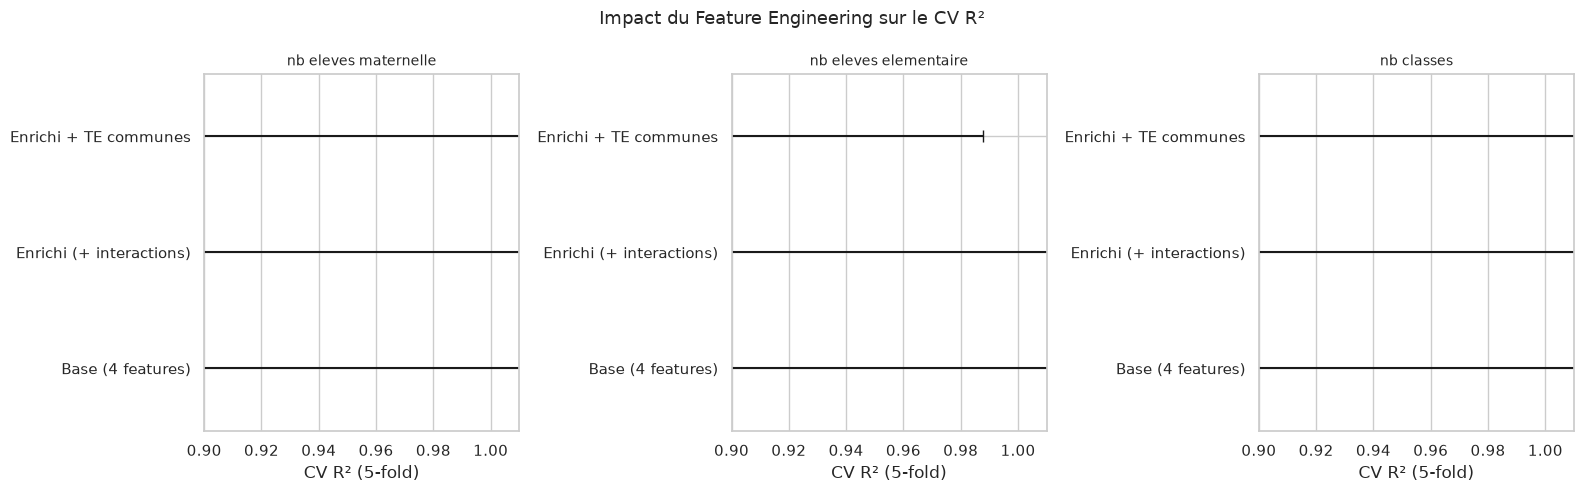

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, target in zip(axes, ALL_TARGETS):
    sub = df_results[df_results['target'] == target]
    bars = ax.barh(
        sub['features'], sub['cv_r2_mean'],
        xerr=sub['cv_r2_std'],
        color=['#5b8db8', '#e07b54', '#6dbf67'],
        capsize=4,
    )
    ax.set_title(target.replace('_', ' '), fontsize=10)
    ax.set_xlabel('CV R² (5-fold)')
    ax.set_xlim(0.9, 1.01)

plt.suptitle('Impact du Feature Engineering sur le CV R²', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Analyse SHAP des features construites

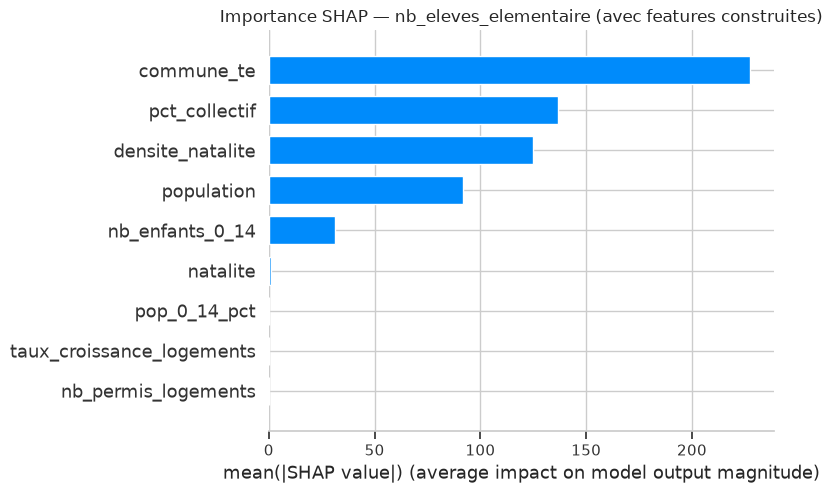

In [8]:
target = 'nb_eleves_elementaire'
best_fs = [f for f in FEATURE_COLUMNS_ENGINEERED if f in df_eng.columns] + ['commune_te']

df_shap = df_eng.copy()
df_shap['commune_te'] = target_encode(df_shap, 'code_insee', target, smoothing=10.0)
df_shap = df_shap.dropna(subset=best_fs + [target])

X = df_shap[best_fs].values
y = df_shap[target].values

final_model = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
final_model.fit(X, y)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(
    shap_values, X,
    feature_names=best_fs,
    plot_type='bar',
    show=False,
)
plt.title(f'Importance SHAP — {target} (avec features construites)', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Conclusions & recommandations

| Feature construite | Impact attendu | Action |
|---|---|---|
| `nb_enfants_0_14` | Corrélation directe avec effectifs | ✅ Ajouter en production |
| `taux_croissance_logements` | Capture les nouvelles zones en développement | ✅ Ajouter en production |
| `commune_te` | Capture l'effet fixe commune | ⚠️ Risque de data leakage — utiliser avec train_mask |
| `densite_natalite` | Interaction utile pour petites communes | ✅ Ajouter si amélioration confirmée |

Pour activer les features d'interaction en production :
```python
from p13.ml.train import train_all
results = train_all(use_engineering=True)
```